## **Case Study: Predicting Attorney Representation in Insurance Claims**
### **Using Logistic Regression**

## **Prediction:**
The Goal is to build a logistic regression model that predicts wheather a claimant will hire (Attorney = 1) or not(Attorney = 0) 

## **Importing Libraries**

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

## **Loading and  Inspecting data**

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\claimants.csv")
df.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


## **Data Shape And Unique Values**

In [3]:
df.shape

(1340, 7)

In [4]:
len(df['CASENUM'].unique())

1283

## **Dropping Irrelevent Column**

In [5]:
# Droping The case number columns as it is not required
df.drop(['CASENUM'],axis=1,inplace=True)

In [6]:
df.head()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038


## **Handaling Missing Values**


In [7]:
df.isnull().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [8]:
## Observation:
# CLMAGE has most missing values (189)
# SEATBELT and  CLMISUR also have missing data.

In [9]:
# Removing NA Values from dataset.
df = df.dropna()
df.shape

(1096, 6)

## **Spliting Data into Features(X) and Target(Y)**

In [10]:
x = df.iloc[:,1:] # [rows ,col]
y = df[['ATTORNEY']]

In [11]:
x.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038


In [12]:
y.head()

,ATTORNEY
0,0
1,1
2,1
3,0
4,1


## **Split into train(80%) and test (20%)**

In [13]:
from  sklearn.model_selection import train_test_split

In [14]:
x_train ,x_test ,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print('Training Set shape: ',x_train.shape)
print("Test Set Shape: ",x_test.shape)

Training Set shape:  (876, 5)
Test Set Shape:  (220, 5)


In [15]:
# Why ?
# Avoid overfitting by evaluating the model on unseen data(x_test)
# Random_state = 42 Ensures reproducibility.

## **Training Logistic Regression Model**

In [16]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train,y_train) # Train only on x_train/y_train

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## **Evaluate on Test Set**

In [17]:
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score

#Predictions on test set
y_pred_test = classifier.predict(x_test) 

In [18]:
# Accuracy
accuracy = accuracy_score(y_test,y_pred_test)
print('Test Accuracy: ',accuracy) 

Test Accuracy:  0.6772727272727272


In [19]:
#  Observation:
# If test accuarcy (~70%) matches training accuaracy (~70%),the model generalizes well
## if the test accuaracy is much lower, the model is overfitting.

In [20]:
classifier.predict_proba (x)

array([[9.99999654e-01, 3.45984944e-07],
       [4.85974592e-01, 5.14025408e-01],
       [4.00591883e-01, 5.99408117e-01],
       ...,
       [2.59655148e-01, 7.40344852e-01],
       [7.34762987e-01, 2.65237013e-01],
       [3.23400218e-01, 6.76599782e-01]], shape=(1096, 2))

In [21]:
# The array shows predicted probabilities for each class(0 and 1).
# Example: [9.999,3.47] means 99.99% probability of class 0 (no attorney) and 0.0000347% for 

In [22]:
## Confusion Matrix
print("Confusion Matrix (Test Set): \n",confusion_matrix(y_test,y_pred_test))

Confusion Matrix (Test Set): 
 [[77 34]
 [37 72]]


In [23]:
#AOC And ROC
auc = roc_auc_score(y_test,classifier.predict_proba(x_test)[:,1])
print('Test AUC: ',auc)

Test AUC:  0.7212579552029093


In [24]:
#y_df = pd.DataFrame({'Actual':y,
#                     'Predicted_prob': classifier.predict(x)})

In [25]:
classifier.predict(x)

array([0, 1, 1, ..., 1, 0, 1], shape=(1096,))

In [26]:
#ROC Curve

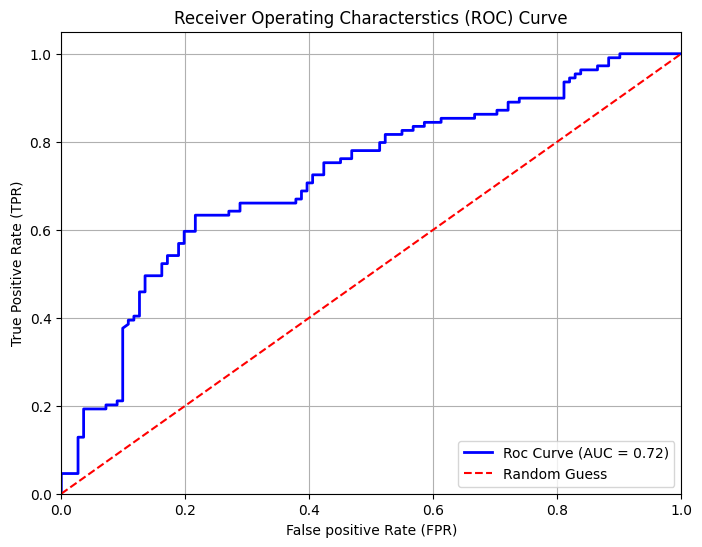

In [27]:
# Import necessary libraries
from sklearn.metrics import roc_auc_score,roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for positivite class (Attorney = 1)
y_pred_prob = classifier.predict_proba(x_test)[:,1]

# Calulate ROC Curve metrices
fpr,tpr,thresholds = roc_curve(y_test,y_pred_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test,y_pred_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color = 'blue',lw = 2,
         label = f'Roc Curve (AUC = {auc_score:.2f})')
plt.plot([0,1],[0,1],color = 'red',linestyle = '--',label = 'Random Guess')

# Customize plot
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characterstics (ROC) Curve')
plt.legend(loc ='lower right')
plt.grid(True)
plt.show()

In [28]:
auc

0.7212579552029093

## **Compare Train Vs Test Performance**

In [29]:
y_pred_train = classifier.predict(x_train)
print("Train Accuaracy: ",accuracy_score(y_train,y_pred_train))

Train Accuaracy:  0.7146118721461188


In [30]:
# Similar accuaracy for train and test --> Good Generalization.
# Train accuaracy >> Test Accuaracy --> Overfitting (need Regularization or feature selection)

In [31]:
# improved model with regularization
classifier = LogisticRegression(penalty='l2',C=0.1,solver='liblinear',random_state=42)
classifier.fit(x_train,y_train)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [32]:
# Why ?
# Penalty = 'l2' reduces overfitting by penalizing large coefficients.
# C = 0.1 increases regularization strength (lower c = stronger penalty).

## **Feature Selection(RFE)**

In [33]:
from sklearn.feature_selection  import RFE

# Select Top 3 Features
selector = RFE(classifier,n_features_to_select=3,step=1)
selector.fit(x_train,y_train)
print("Selected Features: ",x_train.columns[selector.support_])

Selected Features:  Index(['CLMSEX', 'CLMINSUR', 'LOSS'], dtype='object')


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_r

In [34]:
# Removes irrelevent features that may cause overfitting.

In [35]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
cv_score = cross_val_score(classifier,x_train,y_train,cv=5,scoring='accuracy')
print(f'Cross Validation Accuaracy: {cv_score.mean():.3f} ({cv_score.std():.3f})')

Cross Validation Accuaracy: 0.715 (0.018)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_r